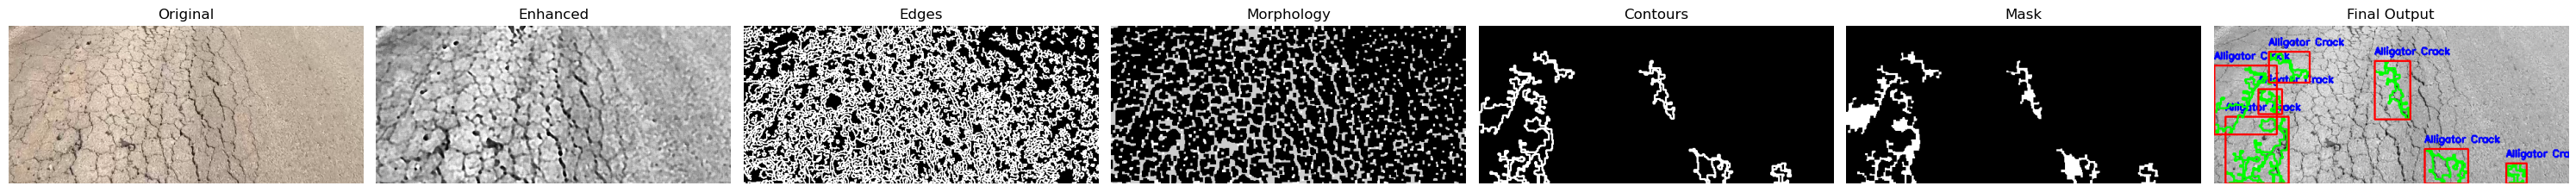

Processing Completed
Total Saved Frames: 41


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================
# CREATE RESULT FOLDERS
# =========================================

os.makedirs("results/original", exist_ok=True)
os.makedirs("results/enhanced", exist_ok=True)
os.makedirs("results/edges", exist_ok=True)
os.makedirs("results/morphology", exist_ok=True)
os.makedirs("results/contours", exist_ok=True)
os.makedirs("results/mask", exist_ok=True)
os.makedirs("results/final", exist_ok=True)

# =========================================
# LOAD VIDEO
# =========================================

video_path = "video8.mp4"
cap = cv2.VideoCapture(video_path)

frame_count = 0
saved_count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # Process every 20th frame
    if frame_count % 20 != 0:
        continue

    # =========================================
    # RESIZE FRAME
    # =========================================

    frame = cv2.resize(frame, (640, 480))

    height, width = frame.shape[:2]

    # =========================================
    # ROAD ROI
    # =========================================

    roi = frame[int(height * 0.5):height, 50:width-50]

    original_roi = roi.copy()

    # =========================================
    # ENHANCEMENT
    # =========================================

    # Grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Median Filter
    median = cv2.medianBlur(gray, 5)

    # Gaussian Blur
    blur = cv2.GaussianBlur(median, (5, 5), 0)

    # CLAHE Enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(blur)

    # Sharpening
    kernel_sharp = np.array([
        [-1, -1, -1],
        [-1,  9, -1],
        [-1, -1, -1]
    ])

    sharpened = cv2.filter2D(
        enhanced,
        -1,
        kernel_sharp
    )

    # =========================================
    # EDGE DETECTION
    # =========================================

    edges = cv2.Canny(
        sharpened,
        100,
        200
    )

    edge_kernel = np.ones((2, 2), np.uint8)

    edges = cv2.dilate(
        edges,
        edge_kernel,
        iterations=1
    )

    # =========================================
    # THRESHOLD SEGMENTATION
    # =========================================

    thresh = cv2.adaptiveThreshold(
        sharpened,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        4
    )

    # Combine threshold + edges
    combined = cv2.bitwise_and(
        thresh,
        edges
    )

    combined = cv2.addWeighted(
        thresh,
        0.8,
        combined,
        0.2,
        0
    )

    # =========================================
    # MORPHOLOGICAL OPERATIONS
    # =========================================

    kernel = np.ones((3, 3), np.uint8)

    # Opening
    opening = cv2.morphologyEx(
        combined,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Closing
    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    morphology_output = closing.copy()

    # =========================================
    # CONTOUR EXTRACTION
    # =========================================

    contours, _ = cv2.findContours(
        closing,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Blank contour image
    contour_output = np.zeros_like(gray)

    # Final Output
    final_output = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    clean_mask = np.zeros_like(closing)

    for cnt in contours:

        area = cv2.contourArea(cnt)

        # Remove tiny regions
        if area < 300:
            continue

        # Remove very large regions
        if area > 8000:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = w / float(h)

        # Ignore thin cracks
        if aspect_ratio > 6 or aspect_ratio < 0.4:
            continue

        # Ignore tall regions
        if h > 150:
            continue

        # Draw contour extraction output
        cv2.drawContours(
            contour_output,
            [cnt],
            -1,
            255,
            2
        )

        # Draw segmentation mask
        cv2.drawContours(
            clean_mask,
            [cnt],
            -1,
            255,
            -1
        )

        # Draw contour on final image
        cv2.drawContours(
            final_output,
            [cnt],
            -1,
            (0, 255, 0),
            2
        )

        # Bounding box
        cv2.rectangle(
            final_output,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

        # Label
        cv2.putText(
            final_output,
            "Alligator Crack",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

    # =========================================
    # SAVE RESULTS
    # =========================================

    cv2.imwrite(
        f"results/original/original_{saved_count}.jpg",
        original_roi
    )

    cv2.imwrite(
        f"results/enhanced/enhanced_{saved_count}.jpg",
        sharpened
    )

    cv2.imwrite(
        f"results/edges/edges_{saved_count}.jpg",
        edges
    )

    cv2.imwrite(
        f"results/morphology/morphology_{saved_count}.jpg",
        morphology_output
    )

    cv2.imwrite(
        f"results/contours/contours_{saved_count}.jpg",
        contour_output
    )

    cv2.imwrite(
        f"results/mask/mask_{saved_count}.jpg",
        clean_mask
    )

    cv2.imwrite(
        f"results/final/final_{saved_count}.jpg",
        final_output
    )

    # Increase saved frame count
    saved_count += 1

    # =========================================
    # DISPLAY ONLY THE 26TH FRAME
    # =========================================

    if saved_count == 26:

        plt.figure(figsize=(30, 5))

        # Original
        plt.subplot(1, 7, 1)
        plt.imshow(cv2.cvtColor(original_roi, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        # Enhanced
        plt.subplot(1, 7, 2)
        plt.imshow(sharpened, cmap="gray")
        plt.title("Enhanced")
        plt.axis("off")

        # Edge Detection
        plt.subplot(1, 7, 3)
        plt.imshow(edges, cmap="gray")
        plt.title("Edges")
        plt.axis("off")

        # Morphology
        plt.subplot(1, 7, 4)
        plt.imshow(morphology_output, cmap="gray")
        plt.title("Morphology")
        plt.axis("off")

        # Contours
        plt.subplot(1, 7, 5)
        plt.imshow(contour_output, cmap="gray")
        plt.title("Contours")
        plt.axis("off")

        # Mask
        plt.subplot(1, 7, 6)
        plt.imshow(clean_mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        # Final Output
        plt.subplot(1, 7, 7)
        plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
        plt.title("Final Output")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

cap.release()
cv2.destroyAllWindows()

print("Processing Completed")
print("Total Saved Frames:", saved_count)